In [2]:
import pandas as pd
import math
from pulp import LpProblem, LpMinimize, LpVariable, lpSum, LpBinary, PULP_CBC_CMD, LpStatus

FILE = "Mother_Dairy_Locations_v2.xlsx"

# -----------------------------
# Helpers
# -----------------------------
def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km."""
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlmb = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlmb/2)**2
    return 2 * R * math.asin(math.sqrt(a))

def read_inputs(file_path):
    fac = pd.read_excel(file_path, sheet_name="FACTORIES")
    dcs_existing = pd.read_excel(file_path, sheet_name="DC's")
    mk = pd.read_excel(file_path, sheet_name="Customers")
    cand = pd.read_excel(file_path, sheet_name="Candidate_DCs")
    params = pd.read_excel(file_path, sheet_name="Parameters")
    demand = pd.read_excel(file_path, sheet_name="Demand")
    caps = pd.read_excel(file_path, sheet_name="Capacities")

    param = dict(zip(params["Parameter"], params["Value"]))
    return fac, dcs_existing, mk, cand, param, demand, caps

def build_distance_tables(plants_df, dcs_df, markets_df):
    # plant -> dc
    dist_p2d = {}
    for _, p in plants_df.iterrows():
        for _, d in dcs_df.iterrows():
            dist_p2d[(p["Node ID"], d["DC_ID"])] = haversine_km(p["Latitude"], p["Longitude"], d["Latitude"], d["Longitude"])

    # dc -> market
    dist_d2m = {}
    for _, d in dcs_df.iterrows():
        for _, m in markets_df.iterrows():
            dist_d2m[(d["DC_ID"], m["Market ID"])] = haversine_km(d["Latitude"], d["Longitude"], m["Latitude"], m["Longitude"])

    return dist_p2d, dist_d2m

def solve_network(
    fac_df, dcs_df, mk_df, demand_df, caps_df, param,
    allow_future_plants: bool,
    allow_future_dcs: bool,
):
    # Filter plants
    plants = fac_df.copy()
    if not allow_future_plants:
        plants = plants[plants["Status"].str.lower().eq("present")].copy()

    # Filter DCs (existing DCs + candidate DCs already merged outside)
    dcs = dcs_df.copy()
    if not allow_future_dcs:
        dcs = dcs[dcs["Status"].str.lower().eq("present") | dcs["Status"].isna()].copy()  # candidates have NaN status

    # Products
    PRODUCTS = ["Milk", "F&V"]

    # Demand dict
    D = {(r["Market ID"], r["Product"]): float(r["Base Demand (tons/day)"]) for _, r in demand_df.iterrows()}

    # Capacity dict
    cap = {(r["Facility ID"], r["Product"]): float(r["Capacity (tons/day)"]) for _, r in caps_df.iterrows()}

    # Costs
    cost_per_ton_km = float(param["cost_per_ton_km_reefer"])
    fixed_cost_dc = float(param["fixed_cost_dc_inr_per_day"])
    handling_dc = float(param["handling_cost_dc_inr_per_ton"])

    max_km_milk = float(param["max_transit_km_milk"])
    max_km_fv = float(param["max_transit_km_fv"])

    # Build distance tables
    dist_p2d, dist_d2m = build_distance_tables(plants, dcs, mk_df)

    # Model
    model = LpProblem("MotherDairy_Baseline_vs_Future", LpMinimize)

    PLANTS = list(plants["Node ID"].unique())
    DCS = list(dcs["DC_ID"].unique())
    MKTS = list(mk_df["Market ID"].unique())

    open_dc = LpVariable.dicts("OpenDC", DCS, lowBound=0, upBound=1, cat=LpBinary)

    # Flows
    x = LpVariable.dicts("ShipPlantToDC", (PLANTS, DCS, PRODUCTS), lowBound=0)
    y = LpVariable.dicts("ShipDCToMarket", (DCS, MKTS, PRODUCTS), lowBound=0)

    # Objective: fixed DC + transport + handling
    model += (
        lpSum(fixed_cost_dc * open_dc[d] for d in DCS)
        + lpSum(cost_per_ton_km * dist_p2d[(p, d)] * x[p][d][prod] for p in PLANTS for d in DCS for prod in PRODUCTS)
        + lpSum(cost_per_ton_km * dist_d2m[(d, m)] * y[d][m][prod] for d in DCS for m in MKTS for prod in PRODUCTS)
        + lpSum(handling_dc * y[d][m][prod] for d in DCS for m in MKTS for prod in PRODUCTS)
    )

    # Demand satisfaction
    for m in MKTS:
        for prod in PRODUCTS:
            model += lpSum(y[d][m][prod] for d in DCS) >= D[(m, prod)]

    # DC flow conservation
    for d in DCS:
        for prod in PRODUCTS:
            model += lpSum(x[p][d][prod] for p in PLANTS) == lpSum(y[d][m][prod] for m in MKTS)

    # Plant capacity
    for p in PLANTS:
        for prod in PRODUCTS:
            model += lpSum(x[p][d][prod] for d in DCS) <= cap.get((p, prod), 0.0)

    # DC capacity (only if opened)
    for d in DCS:
        for prod in PRODUCTS:
            model += lpSum(y[d][m][prod] for m in MKTS) <= cap.get((d, prod), 0.0) * open_dc[d]

    # Cold-chain max distance constraints (hard lane feasibility)
    for p in PLANTS:
        for d in DCS:
            for prod in PRODUCTS:
                max_km = max_km_milk if prod == "Milk" else max_km_fv
                if dist_p2d[(p, d)] > max_km:
                    model += x[p][d][prod] == 0

    for d in DCS:
        for m in MKTS:
            for prod in PRODUCTS:
                max_km = max_km_milk if prod == "Milk" else max_km_fv
                if dist_d2m[(d, m)] > max_km:
                    model += y[d][m][prod] == 0

    # Solve
    model.solve(PULP_CBC_CMD(msg=0))

    status = LpStatus[model.status]
    chosen_dcs = [d for d in DCS if open_dc[d].value() is not None and open_dc[d].value() > 0.5]
    total_cost = model.objective.value()

    # Compute average weighted distance DC->Market (simple indicator)
    shipped = []
    for d in DCS:
        for m in MKTS:
            for prod in PRODUCTS:
                val = y[d][m][prod].value()
                if val and val > 1e-6:
                    shipped.append((val, dist_d2m[(d, m)]))
    avg_km = (sum(q * km for q, km in shipped) / sum(q for q, _ in shipped)) if shipped else None

    return {
        "status": status,
        "total_cost": total_cost,
        "chosen_dcs": chosen_dcs,
        "avg_dc_to_market_km": avg_km
    }

# -----------------------------
# Run baseline vs future
# -----------------------------
fac, dcs_existing, mk, cand, param, demand, caps = read_inputs(FILE)

# Build a combined DC table:
# - existing DCs keep their Status
# - candidate DCs are additional options (Status left blank/NaN)
dcs_existing = dcs_existing.rename(columns={"Node ID": "DC_ID"})
cand = cand.rename(columns={"Candidate DC ID": "DC_ID"})
cand["Node Type"] = "Candidate DC"
cand["City / Location"] = cand["City"]
cand["Status"] = None
cand = cand[["DC_ID", "Node Type", "State", "City / Location", "Status", "Latitude", "Longitude"]]

dcs_existing = dcs_existing[["DC_ID", "Node Type", "State", "City / Location", "Status", "Latitude", "Longitude"]]
dcs_all = pd.concat([dcs_existing, cand], ignore_index=True)

# Baseline: only present plants, only present existing DCs + candidates
res_base = solve_network(
    fac_df=fac, dcs_df=dcs_all, mk_df=mk, demand_df=demand, caps_df=caps, param=param,
    allow_future_plants=False,
    allow_future_dcs=False,
)

# Future: present + future plants, and allow future DCs as well
res_future = solve_network(
    fac_df=fac, dcs_df=dcs_all, mk_df=mk, demand_df=demand, caps_df=caps, param=param,
    allow_future_plants=True,
    allow_future_dcs=True,
)

print("\n=== BASELINE (Present plants only) ===")
print("Status:", res_base["status"])
print("Total cost (₹/day):", round(res_base["total_cost"], 2))
print("Chosen DCs:", res_base["chosen_dcs"])
print("Avg DC->Market km:", None if res_base["avg_dc_to_market_km"] is None else round(res_base["avg_dc_to_market_km"], 1))

print("\n=== FUTURE (Present + Future plants) ===")
print("Status:", res_future["status"])
print("Total cost (₹/day):", round(res_future["total_cost"], 2))
print("Chosen DCs:", res_future["chosen_dcs"])
print("Avg DC->Market km:", None if res_future["avg_dc_to_market_km"] is None else round(res_future["avg_dc_to_market_km"], 1))

if res_base["status"] == "Optimal" and res_future["status"] == "Optimal":
    benefit = res_base["total_cost"] - res_future["total_cost"]
    print("\n=== BENEFIT CHECK ===")
    print("Cost reduction (₹/day) with future locations:", round(benefit, 2))
    if benefit > 0:
        print("✅ Future network is beneficial (lower expected cost).")
    else:
        print("⚠️ Future network not beneficial on cost (given current assumptions). Try adjusting demand/cost/capacity.")



=== BASELINE (Present plants only) ===
Status: Infeasible
Total cost (₹/day): 1195455.13
Chosen DCs: ['CD3']
Avg DC->Market km: 721.1

=== FUTURE (Present + Future plants) ===
Status: Optimal
Total cost (₹/day): 1353758.99
Chosen DCs: ['CD2', 'CD3', 'CD8', 'CD14']
Avg DC->Market km: 388.8


In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)

DAYS = 365
mean_demand = 100
std_dev = 15

min_inv = 300
max_inv = 600
lead_time = 3

inventory = max_inv
pipeline = []
stockouts = 0
served = 0
total_demand = 0

daily_inventory = []

for day in range(DAYS):
    demand = max(0, int(np.random.normal(mean_demand, std_dev)))
    total_demand += demand

    # Receive replenishment
    if pipeline and pipeline[0][0] == day:
        inventory += pipeline.pop(0)[1]

    # Fulfil demand
    if inventory >= demand:
        inventory -= demand
        served += demand
    else:
        served += inventory
        stockouts += (demand - inventory)
        inventory = 0

    # Reorder decision
    if inventory < min_inv:
        order_qty = max_inv - inventory
        pipeline.append((day + lead_time, order_qty))

    daily_inventory.append(inventory)

service_level = served / total_demand

print("Service Level:", round(service_level, 3))
print("Total Stockouts:", stockouts)


Service Level: 1.0
Total Stockouts: 6


In [4]:
DISRUPTION_START = 120
DISRUPTION_END = 180

inventory = max_inv
pipeline = []
served = 0
total_demand = 0

for day in range(DAYS):
    demand = max(0, int(np.random.normal(mean_demand, std_dev)))
    total_demand += demand

    # Block replenishment during disruption
    if pipeline and pipeline[0][0] == day:
        if not (DISRUPTION_START <= day <= DISRUPTION_END):
            inventory += pipeline.pop(0)[1]
        else:
            pipeline.pop(0)

    if inventory >= demand:
        inventory -= demand
        served += demand
    else:
        served += inventory
        inventory = 0

    if inventory < min_inv and not (DISRUPTION_START <= day <= DISRUPTION_END):
        pipeline.append((day + lead_time, max_inv - inventory))

service_level_risk = served / total_demand
print("Service Level under Disruption:", round(service_level_risk, 3))


Service Level under Disruption: 0.86


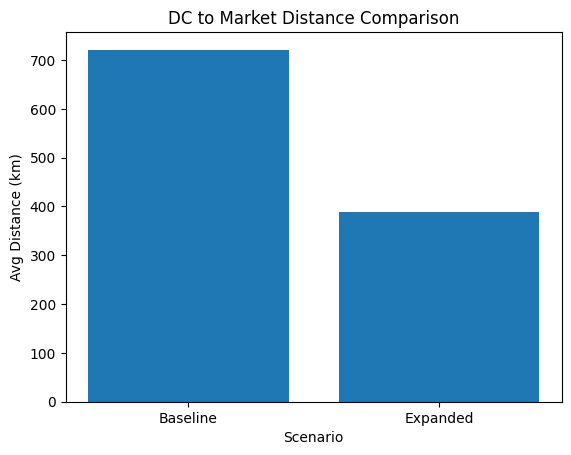

In [5]:
import matplotlib.pyplot as plt

scenarios = ["Baseline", "Expanded"]
avg_dist = [721, 389]

plt.figure()
plt.bar(scenarios, avg_dist)
plt.xlabel("Scenario")
plt.ylabel("Avg Distance (km)")
plt.title("DC to Market Distance Comparison")
plt.show()


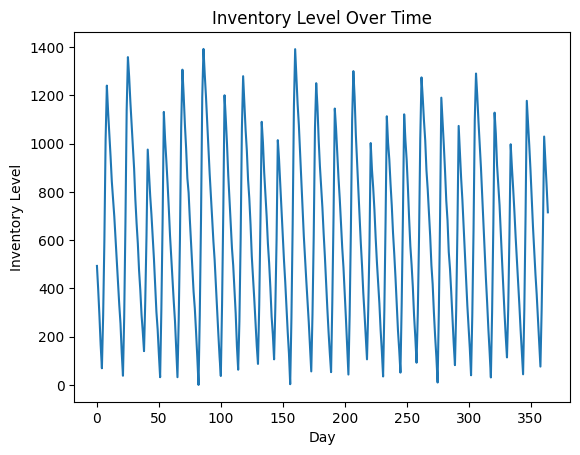

In [6]:
plt.figure()
plt.plot(daily_inventory)
plt.xlabel("Day")
plt.ylabel("Inventory Level")
plt.title("Inventory Level Over Time")
plt.show()
